IMPORT LIBRARIES

In [2]:
import pandas as pd 
import numpy as np 

LOAD THE DATASET

In [4]:
df=pd.read_csv("C:/Users/ACER/Downloads/UK_House_Price_Prediction.csv")

In [6]:
df

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district
0,735000,2017-08-07,LE17 5AP,D,N,F,CLAYBROOKE COURT,CLAYBROOKE PARVA,LUTTERWORTH,HARBOROUGH
1,160000,2023-02-03,SA11 4BD,T,N,F,GORED COTTAGES,MELINCOURT,NEATH,NEATH PORT TALBOT
2,176500,2015-01-06,ME3 0DQ,S,N,F,GREEN LANE,ISLE OF GRAIN,ROCHESTER,MEDWAY
3,625000,2021-10-13,RH20 3EU,D,N,F,LINFIELD COPSE,THAKEHAM,PULBOROUGH,HORSHAM
4,202000,2019-09-27,SN13 8EN,S,N,F,CLYDESDALE ROAD,BOX,CORSHAM,WILTSHIRE
...,...,...,...,...,...,...,...,...,...,...
89995,295000,2021-08-13,GL11 5UW,D,N,F,PEVELANDS,CAM,DURSLEY,STROUD
89996,325000,2021-12-07,WS3 3UJ,D,N,F,GLENEAGLES ROAD,BLOXWICH,WALSALL,WALSALL
89997,167000,2015-11-06,BD17 5LR,S,N,F,CORNWALL CRESCENT,BAILDON,SHIPLEY,BRADFORD
89998,80000,2023-09-26,DN4 7RZ,F,N,L,STOOPS LANE,BESSACARR,DONCASTER,DONCASTER


In [9]:
df.columns

Index(['price', 'date', 'postcode', 'property_type', 'new_build', 'freehold',
       'street', 'locality', 'town', 'district'],
      dtype='object')

In [11]:
#to find the no. of records & columns
df.shape

(90000, 10)

In [13]:
# use the info method to find the number of non null entries and data Type of each columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   price          90000 non-null  int64 
 1   date           90000 non-null  object
 2   postcode       90000 non-null  object
 3   property_type  90000 non-null  object
 4   new_build      90000 non-null  object
 5   freehold       90000 non-null  object
 6   street         90000 non-null  object
 7   locality       90000 non-null  object
 8   town           90000 non-null  object
 9   district       90000 non-null  object
dtypes: int64(1), object(9)
memory usage: 6.9+ MB


DATA PREPROCESSING

In [19]:
#to check the null values in a column
df.isnull().sum()

price            0
date             0
postcode         0
property_type    0
new_build        0
freehold         0
street           0
locality         0
town             0
district         0
dtype: int64

In [23]:
#to check if kisi column m koi null values hai ya nahi
df.isnull().values.any()

False

In [25]:
#check dupicate values
df.duplicated().sum()

43

In [27]:
df.drop_duplicates(inplace=True)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89957 entries, 0 to 89999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   price          89957 non-null  int64 
 1   date           89957 non-null  object
 2   postcode       89957 non-null  object
 3   property_type  89957 non-null  object
 4   new_build      89957 non-null  object
 5   freehold       89957 non-null  object
 6   street         89957 non-null  object
 7   locality       89957 non-null  object
 8   town           89957 non-null  object
 9   district       89957 non-null  object
dtypes: int64(1), object(9)
memory usage: 7.5+ MB


OUTLIER ANALYSIS

In [32]:
import seaborn as sns

<Axes: ylabel='price'>

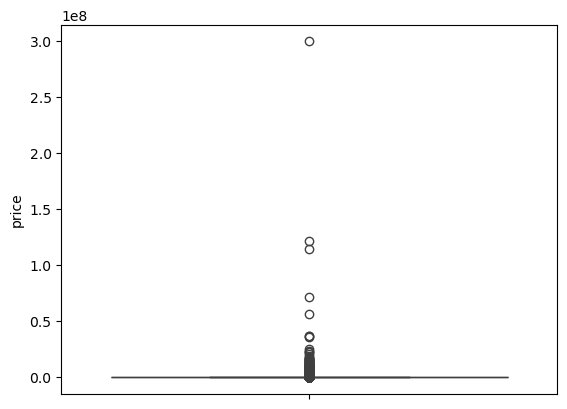

In [34]:
# Boxplot to visualize outliers in the Price column
sns.boxplot(y='price', data=df)
#bhot outlier h qk price hugh tk outlier il raha hai

In [38]:
# Calculate the first quartile (25%)
# Calculate the second quartile (Median - 50%)
# Calculate the third quartile (75%)
Q1 = df['price'].quantile(0.25)
Q2 = df['price'].quantile(0.50)
Q3 = df['price'].quantile(0.75)

In [46]:
Q3

366000.0

In [48]:
# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1
IQR

206000.0

In [44]:
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

In [50]:
upper_bound

675000.0

In [52]:
# Remove the outliers & Keep only those rows where the price is between the lower and upper bounds
df = df[(df['price'] < upper_bound) & (df['price'] > lower_bound)]

<Axes: ylabel='price'>

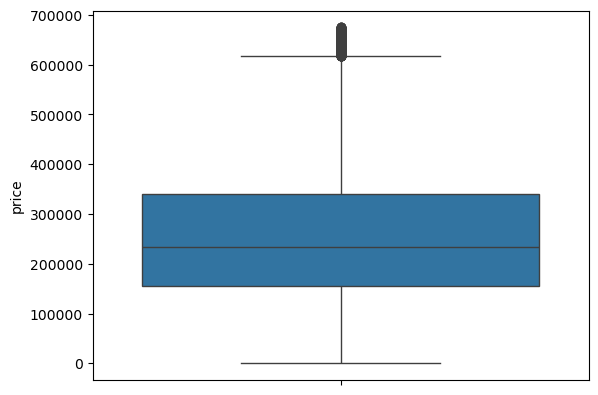

In [54]:
#boxplot after removing outliers
sns.boxplot(y='price', data=df)

In [56]:
# List of numeric columns for outlier analysis
columns = ['price']
# Remove outliers using iqr method
for c in columns:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    # Keep only values jo iqr range mai h
    df = df[(df[c] < upper_bound) & (df[c] > lower_bound)]

<Axes: ylabel='price'>

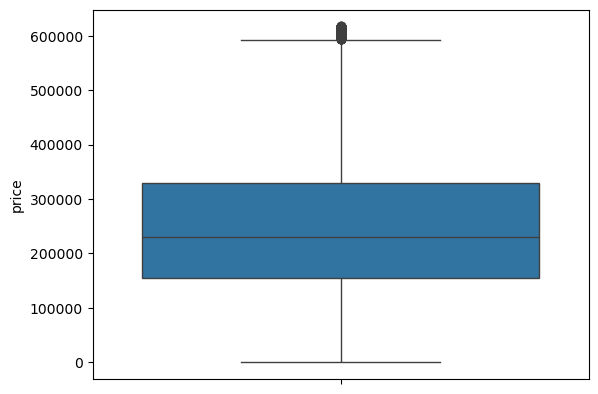

In [58]:
# Boxplot after removing outliers
sns.boxplot(y='price', data=df)

ENCODING

In [61]:
df

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district
1,160000,2023-02-03,SA11 4BD,T,N,F,GORED COTTAGES,MELINCOURT,NEATH,NEATH PORT TALBOT
2,176500,2015-01-06,ME3 0DQ,S,N,F,GREEN LANE,ISLE OF GRAIN,ROCHESTER,MEDWAY
4,202000,2019-09-27,SN13 8EN,S,N,F,CLYDESDALE ROAD,BOX,CORSHAM,WILTSHIRE
5,249950,2019-09-06,LS12 5FA,S,Y,F,FARNLEY PARK VIEW,FARNLEY,LEEDS,LEEDS
7,185000,2023-12-18,NR10 5PB,S,N,F,NELSON WAY,HEVINGHAM,NORWICH,BROADLAND
...,...,...,...,...,...,...,...,...,...,...
89994,111000,2015-11-05,NG11 9HE,S,N,F,HAVENWOOD RISE,CLIFTON,NOTTINGHAM,CITY OF NOTTINGHAM
89995,295000,2021-08-13,GL11 5UW,D,N,F,PEVELANDS,CAM,DURSLEY,STROUD
89996,325000,2021-12-07,WS3 3UJ,D,N,F,GLENEAGLES ROAD,BLOXWICH,WALSALL,WALSALL
89997,167000,2015-11-06,BD17 5LR,S,N,F,CORNWALL CRESCENT,BAILDON,SHIPLEY,BRADFORD


In [63]:
from sklearn.preprocessing import LabelEncoder

In [65]:
#store encoder in variable le
le=LabelEncoder()

In [67]:
df['property_type'] = le.fit_transform(df['property_type'])

In [69]:
df['new_build'] = le.fit_transform(df['new_build'])

In [71]:
df['freehold'] = le.fit_transform(df['freehold'])

In [73]:
df

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district
1,160000,2023-02-03,SA11 4BD,4,0,0,GORED COTTAGES,MELINCOURT,NEATH,NEATH PORT TALBOT
2,176500,2015-01-06,ME3 0DQ,3,0,0,GREEN LANE,ISLE OF GRAIN,ROCHESTER,MEDWAY
4,202000,2019-09-27,SN13 8EN,3,0,0,CLYDESDALE ROAD,BOX,CORSHAM,WILTSHIRE
5,249950,2019-09-06,LS12 5FA,3,1,0,FARNLEY PARK VIEW,FARNLEY,LEEDS,LEEDS
7,185000,2023-12-18,NR10 5PB,3,0,0,NELSON WAY,HEVINGHAM,NORWICH,BROADLAND
...,...,...,...,...,...,...,...,...,...,...
89994,111000,2015-11-05,NG11 9HE,3,0,0,HAVENWOOD RISE,CLIFTON,NOTTINGHAM,CITY OF NOTTINGHAM
89995,295000,2021-08-13,GL11 5UW,0,0,0,PEVELANDS,CAM,DURSLEY,STROUD
89996,325000,2021-12-07,WS3 3UJ,0,0,0,GLENEAGLES ROAD,BLOXWICH,WALSALL,WALSALL
89997,167000,2015-11-06,BD17 5LR,3,0,0,CORNWALL CRESCENT,BAILDON,SHIPLEY,BRADFORD


In [81]:
df['property_type'].unique()

array([4, 3, 2, 1, 0])

In [79]:
df['new_build'].unique()

array([0, 1])

In [83]:
df['freehold'].unique()

array([0, 1])

In [77]:
df.head(1)

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district
1,160000,2023-02-03,SA11 4BD,4,0,0,GORED COTTAGES,MELINCOURT,NEATH,NEATH PORT TALBOT


In [89]:
col = ['date', 'postcode', 'property_type', 'new_build',
       'freehold', 'street', 'locality', 'town', 'district']
#encoding numerical nahi categorical wale saare columns pe hogi
for c in col:
    df[c] = le.fit_transform(df[c])

In [87]:
df

,price,date,postcode,property_type,new_build,freehold,street,locality,town,district
1,160000,2179,54510,4,0,0,14995,5458,569,191
2,176500,2,34906,3,0,0,15376,4386,682,179
4,202000,1273,57551,3,0,0,8248,969,223,342
5,249950,1258,31051,3,1,0,12724,2918,463,166
7,185000,2410,42562,3,0,0,25559,3976,597,36
...,...,...,...,...,...,...,...,...,...,...
89994,111000,229,38091,3,0,0,16752,1848,598,70
89995,295000,1780,21425,0,0,0,28325,1433,278,289
89996,325000,1869,68208,0,0,0,14716,857,870,319
89997,167000,230,3627,3,0,0,8976,401,732,29


LINEAR REGRESSION

In [ ]:
# X contains all the independent (feature) columns
# Features used for prediction:
# date, postcode, property_type, new_build,freehold, street, locality, town and district
# y contains the dependent (target) column i.e. Price

In [91]:
# Here, all input features are stored in X
# The output (house price) is stored in y

In [93]:
# Select all columns except the first column (price)
X = df.iloc[:,1:].values

In [95]:
X

array([[ 2179, 54510,     4, ...,  5458,   569,   191],
       [    2, 34906,     3, ...,  4386,   682,   179],
       [ 1273, 57551,     3, ...,   969,   223,   342],
       ...,
       [ 1869, 68208,     0, ...,   857,   870,   319],
       [  230,  3627,     3, ...,   401,   732,    29],
       [ 2349, 19178,     1, ...,   659,   264,    92]], dtype=int64)

In [97]:
# Select only the first column (price)
Y = df.iloc[:,0].values

In [99]:
Y

array([160000, 176500, 202000, ..., 325000, 167000,  80000], dtype=int64)

In [101]:
# split the data into training and testing 
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3, random_state=41)
# 1. X_train: training data (input features)& model isse seekhega
# 2. X_test: testing data (input features) & model ko yeh pehle nahi dikhaya gaya
# 3. Y_train: training data ka answer (actual output)&  model ko sikhane ke liye correct answer
# 4. Y_test: testing data ka answer & compare karne ke liye ki model kitna sahi hai
#X=questions
# Y=answers

# Train part:

# student ko padhana
# X_train = questions practice ke liye
# Y_train = answers check karne ke liye
# Test part:
#  exam

# X_test = exam questions
# Y_test = correct answer key

In [103]:
X_train.shape

(58391, 9)

In [105]:
X_test.shape

(25026, 9)

STANDARDISATION

In [108]:
#Standardization: to improve accuracy
from sklearn.preprocessing import StandardScaler
#Standardization = x-mu/sigma
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.fit_transform(X_test)

In [110]:
X_train

array([[-0.01295346, -1.40957234, -0.67770752, ...,  0.67019767,
        -1.32075712,  0.32421889],
       [ 0.85771163, -0.90945145,  0.55332077, ..., -0.10205709,
        -1.5395817 , -1.60490052],
       [-1.41617537, -0.46054717,  0.55332077, ...,  0.80630803,
        -0.81896971,  0.89824954],
       ...,
       [ 0.95348479, -0.02299116,  0.55332077, ...,  0.29760912,
         0.92785412,  1.14291834],
       [-1.15932916, -1.23611282,  0.55332077, ..., -1.39564701,
        -1.16607078,  1.2558424 ],
       [-0.44393268, -1.25602209,  0.55332077, ..., -1.51442766,
         0.61470859,  0.55006701]])

In [112]:
X_test

array([[ 0.19888712,  0.67940537, -1.28104734, ...,  0.45510773,
        -0.95215206, -0.16420371],
       [-1.0230268 , -1.19017572,  0.55856232, ..., -1.51623014,
         1.67644701,  1.62338429],
       [-1.44538084, -0.36556146,  0.55856232, ..., -0.28760578,
         0.30912098, -0.07908048],
       ...,
       [ 0.02411993,  0.93127249, -1.28104734, ...,  1.16653015,
         0.79014704,  0.62082171],
       [-1.33032577,  0.05599559, -1.28104734, ...,  0.92627222,
        -1.56195674, -1.48834298],
       [ 0.01392518,  1.47225575, -1.28104734, ..., -0.15488845,
         1.14618207,  1.06535417]])

In [114]:
#build the model
from sklearn.linear_model import LinearRegression

In [116]:
lr=LinearRegression()

In [118]:
# X contains all input features except the target column (price)
X = df.iloc[:, 1:].values
# Y contains the target variable (House Price)
Y = df.iloc[:, 0].values
from sklearn.model_selection import train_test_split
# Split the dataset into 70% training & 30% testing data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=41
)

In [120]:
lr.fit(X_train, Y_train)

LinearRegression()

In [122]:
Y_pred=lr.predict(X_test)
#X_test wo 30% data hai

In [124]:
Y_pred

array([335965.71515338, 223471.82670535, 115656.90839023, ...,
       328932.57907507, 323448.98925164, 328430.51996112])

In [126]:
#Evaluate the model now
from sklearn.metrics import mean_squared_error 

In [128]:
mean_squared_error(Y_test,Y_pred)
#compare actual value and predicted value
#high value high so error is high

12586816386.178087

In [130]:
from sklearn.metrics import r2_score

In [134]:
r2_score(Y_test,Y_pred)

0.2509273266087957

In [138]:
#Matlab 25% ka variation hai house prices mai
#error bhot high aaya hai matlab predict kr rha hai but performance moderate h ok ok